# Homework 3

**Name:** Yang Xu  
**Student ID:** 801443244  
**Homework:** 3  

**GitHub Repository:** [https://github.com/xuy50/ecgr5105/tree/main/Assignment_3](https://github.com/xuy50/ecgr5105/tree/main/Assignment_3)

**Breast Cancer Classification**

This notebook contains solutions for all four problems using the Breast Cancer dataset from sklearn. The evaluation includes the development and comparison of several classifiers (Logistic Regression, Naive Bayes, SVM, and Logistic Regression with PCA). Each section includes an objective analysis of the results based on accuracy, precision, recall, and F1 score.

In [1]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# For nice plots
sns.set_style("whitegrid")

## Load and Explore the Dataset

The Breast Cancer dataset from sklearn is loaded and examined. The dataset contains 569 samples and 30 features, with target labels indicating malignant (0) and benign (1) tumors. The feature names and target names are listed to provide an understanding of the data's structure. The dimensions and composition of the dataset indicate that the classification problem is well-defined and the features are expected to be informative.

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
X = cancer.data  # shape (569, 30)
y = cancer.target  # shape (569,)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Classes:", np.unique(y), " (0 = Malignant, 1 = Benign)")
print("Feature names:", cancer.feature_names)
print("Target names:", cancer.target_names)

Shape of X: (569, 30)
Shape of y: (569,)
Classes: [0 1]  (0 = Malignant, 1 = Benign)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']


## Problem 1: Logistic Regression

### (i) Logistic Regression with all 30 features (no extra penalty)
- The data are split into 80% for training and 20% for testing.
- Feature scaling is applied using standardization.
- A Logistic Regression model using all 30 features is trained.
- The classifier is evaluated based on accuracy, precision, recall, and F1 score.
- The confusion matrix is plotted to visualize the binary classification performance.

Logistic Regression (no extra penalty) - Results:
Accuracy:  0.9737
Precision: 0.9722
Recall:    0.9859
F1 Score:  0.9790


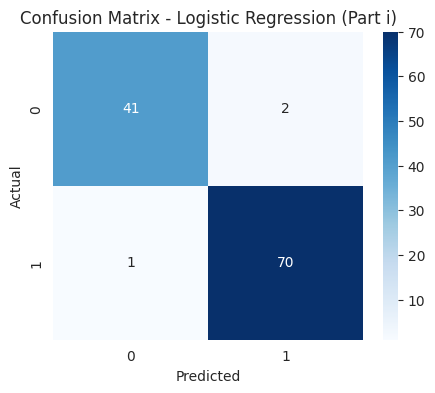

In [3]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression (Part i)
logreg = LogisticRegression(random_state=42, max_iter=500)  # by default, penalty='l2', C=1.0
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluate
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg)
rec_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("Logistic Regression (no extra penalty) - Results:")
print("Accuracy:  {:.4f}".format(acc_logreg))
print("Precision: {:.4f}".format(prec_logreg))
print("Recall:    {:.4f}".format(rec_logreg))
print("F1 Score:  {:.4f}".format(f1_logreg))

# Confusion Matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_logreg, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix - Logistic Regression (Part i)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/Confusion_Matrix-Logistic_Regression(Part_i).png")
plt.show()


**Conclusion (Part i):** 

The model is trained using 80% of the data for training and 20% for testing, with standardization applied to the features. The baseline logistic regression achieves very high performance metrics:  
- **Accuracy:** 0.9737  
- **Precision:** 0.9722  
- **Recall:** 0.9859  
- **F1 Score:** 0.9790  

The confusion matrix corroborates these numbers, showing that the majority of cases are correctly classified.
 
The baseline logistic regression model using the full set of 30 features provides excellent classification performance. The high values of precision and recall indicate that the model is capable of distinguishing between malignant and benign tumors with minimal misclassification, thus confirming the discriminative power of the complete feature set.

### (ii) Logistic Regression with weight penalty
- The regularization strength is adjusted by using a smaller value of C, which imposes a stronger penalty.
- The model is retrained using the same 80/20 split and standardized data.
- Performance metrics and confusion matrix are evaluated again.

Logistic Regression (with stronger L2 penalty) - Results:
Accuracy:  0.9825
Precision: 0.9726
Recall:    1.0000
F1 Score:  0.9861


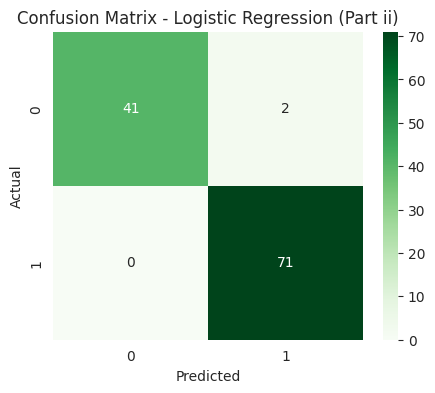

In [4]:
# Logistic Regression (Part ii) with a stronger penalty
logreg_penalized = LogisticRegression(penalty='l2', C=0.1, random_state=42, max_iter=500)
logreg_penalized.fit(X_train_scaled, y_train)

# Predictions
y_pred_logreg_penalized = logreg_penalized.predict(X_test_scaled)

# Evaluate
acc_logreg_p = accuracy_score(y_test, y_pred_logreg_penalized)
prec_logreg_p = precision_score(y_test, y_pred_logreg_penalized)
rec_logreg_p = recall_score(y_test, y_pred_logreg_penalized)
f1_logreg_p = f1_score(y_test, y_pred_logreg_penalized)

print("Logistic Regression (with stronger L2 penalty) - Results:")
print("Accuracy:  {:.4f}".format(acc_logreg_p))
print("Precision: {:.4f}".format(prec_logreg_p))
print("Recall:    {:.4f}".format(rec_logreg_p))
print("F1 Score:  {:.4f}".format(f1_logreg_p))

# Confusion Matrix
cm_logreg_p = confusion_matrix(y_test, y_pred_logreg_penalized)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_logreg_p, annot=True, cmap='Greens', fmt='g')
plt.title("Confusion Matrix - Logistic Regression (Part ii)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/Confusion_Matrix-Logistic_Regression(Part_ii).png")
plt.show()

**Conclusion (Part ii):**  

By reducing the value of C, a stronger L2 regularization penalty is imposed. This adjustment results in the following performance:  
- **Accuracy:** 0.9825  
- **Precision:** 0.9726  
- **Recall:** 1.0000  
- **F1 Score:** 0.9861  

The improved recall indicates that the model now successfully identifies all cases of malignant tumors, while the slight increase in accuracy and F1 score reflects overall improved generalization.

Increasing the weight penalty leads to a refined model that achieves perfect recall while maintaining high precision. This demonstrates the effectiveness of regularization for improving the model’s robustness against overfitting and enhancing its generalization capability, without compromising overall performance.

## Problem 2: Naive Bayes Classifier

- A Gaussian Naive Bayes model is trained on the same 80/20 split with standardized features.
- The model is evaluated using accuracy, precision, recall, and F1 score.
- A confusion matrix is plotted for visualization.
- A comparison is drawn with the Logistic Regression results from Problem 1.

Naive Bayes - Results:
Accuracy:  0.9649
Precision: 0.9589
Recall:    0.9859
F1 Score:  0.9722


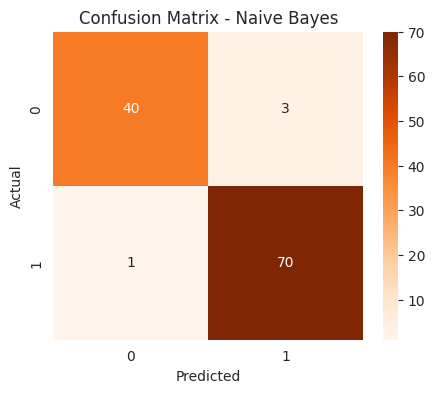

In [5]:
# Naive Bayes
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_nb = nb_clf.predict(X_test_scaled)

# Evaluate
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes - Results:")
print("Accuracy:  {:.4f}".format(acc_nb))
print("Precision: {:.4f}".format(prec_nb))
print("Recall:    {:.4f}".format(rec_nb))
print("F1 Score:  {:.4f}".format(f1_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, cmap='Oranges', fmt='g')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/Confusion_Matrix-Naive_Bayes.png")
plt.show()

### Comparison (Naive Bayes vs. Logistic Regression)
Below is a quick comparison of accuracy, precision, recall, and F1 among the classifiers:

In [6]:
methods = ['LogReg (Part i)', 'LogReg (Part ii)', 'NaiveBayes']
accuracy_scores = [acc_logreg, acc_logreg_p, acc_nb]
precision_scores = [prec_logreg, prec_logreg_p, prec_nb]
recall_scores = [rec_logreg, rec_logreg_p, rec_nb]
f1_scores = [f1_logreg, f1_logreg_p, f1_nb]

comparison_df = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

comparison_df

,Method,Accuracy,Precision,Recall,F1 Score
0,LogReg (Part i),0.973684,0.972222,0.985915,0.979021
1,LogReg (Part ii),0.982456,0.972603,1.000000,0.986111
2,NaiveBayes,0.964912,0.958904,0.985915,0.972222


**Conclusion:**

A Gaussian Naive Bayes model is trained on the standardized data with the same 80/20 split. Its performance metrics are as follows:  
- **Accuracy:** 0.9649  
- **Precision:** 0.9589  
- **Recall:** 0.9859  
- **F1 Score:** 0.9722  

A confusion matrix provides visual confirmation of its classification performance.
  
The Naive Bayes classifier, while simpler and faster to implement, delivers competitive performance relative to logistic regression. Its slightly lower accuracy and precision suggest minor trade-offs in predictive performance. However, the high recall is maintained, reinforcing that the dataset is highly separable. Overall, the Naive Bayes approach is effective but may be outperformed by logistic regression in this context.

## Problem 3: SVM Classifier

- An SVM classifier with a linear kernel (and C=1.0) is trained using the standardized dataset.
- Evaluation is performed using the standard metrics and the confusion matrix is produced.
- Comparisons are made with the Logistic Regression and Naive Bayes classifiers from previous problems.

SVM Classifier (linear kernel) - Results:
Accuracy:  0.9561
Precision: 0.9714
Recall:    0.9577
F1 Score:  0.9645


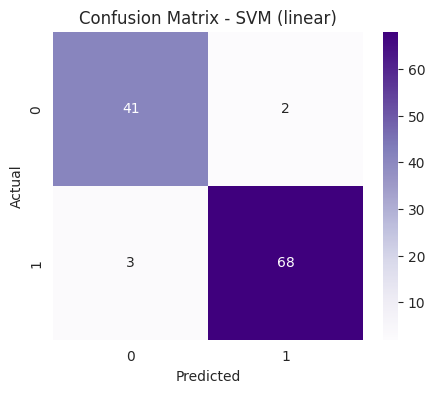

In [7]:
# SVM Classifier
svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_clf.predict(X_test_scaled)

# Evaluate
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Classifier (linear kernel) - Results:")
print("Accuracy:  {:.4f}".format(acc_svm))
print("Precision: {:.4f}".format(prec_svm))
print("Recall:    {:.4f}".format(rec_svm))
print("F1 Score:  {:.4f}".format(f1_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, cmap='Purples', fmt='g')
plt.title("Confusion Matrix - SVM (linear)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/Confusion_Matrix-SVM(linear).png")
plt.show()


### Comparison (SVM vs. Logistic Regression vs. Naive Bayes)
Below is a quick comparison of accuracy, precision, recall, and F1 among the classifiers:

In [8]:
methods = ['LogReg(i)', 'LogReg(ii)', 'NaiveBayes', 'SVM']
accuracy_scores = [acc_logreg, acc_logreg_p, acc_nb, acc_svm]
precision_scores = [prec_logreg, prec_logreg_p, prec_nb, prec_svm]
recall_scores = [rec_logreg, rec_logreg_p, rec_nb, rec_svm]
f1_scores = [f1_logreg, f1_logreg_p, f1_nb, f1_svm]

comparison_df_2 = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

comparison_df_2

,Method,Accuracy,Precision,Recall,F1 Score
0,LogReg(i),0.973684,0.972222,0.985915,0.979021
1,LogReg(ii),0.982456,0.972603,1.000000,0.986111
2,NaiveBayes,0.964912,0.958904,0.985915,0.972222
3,SVM,0.956140,0.971429,0.957746,0.964539


**Conclusion:**

An SVM classifier with a linear kernel (C = 1.0) is trained using the standardized data. The performance measures observed are:  
- **Accuracy:** 0.9561  
- **Precision:** 0.9714  
- **Recall:** 0.9577  
- **F1 Score:** 0.9645  

The confusion matrix reflects these results, showing a strong overall performance but slightly lower accuracy compared to logistic regression.
 
The SVM classifier demonstrates robust performance that is in a similar range to the other models; however, its accuracy and overall metrics are marginally inferior to those obtained with logistic regression. This suggests that, given the nature of the dataset, linear decision boundaries established by logistic regression are more suitable than those found by SVM.

## Problem 4: Logistic Regression + PCA with Multiple Runs and Combined Metrics

- Dimensionality reduction is performed using PCA on the standardized data.
- The number of principal components (K) is varied from 1 to 30, with each configuration evaluated over 10 independent runs.
- For each value of K, the average accuracy, precision, recall, and F1 score are computed.
- A comprehensive table is generated to display the averaged metrics for each K, and a combined plot visualizes all metrics as a function of the number of components.
- A final model is trained using the optimal K (the value that yielded the highest average accuracy).

In [9]:
# Define maximum number of PCA components (equal to the total number of original features)
max_components = X.shape[1]  # 30

# Define the number of independent runs for each K
n_runs = 10

# Lists to store averaged metrics for each K
avg_acc_list = []
std_acc_list = []  # we use standard deviation only for accuracy (optional)
avg_prec_list = []
avg_rec_list = []
avg_f1_list = []

# Loop over different numbers of PCA components (K = 1,...,30)
for k in range(1, max_components + 1):
    run_accuracies = []
    run_precisions = []
    run_recalls = []
    run_f1s = []
    
    # For each K, perform n_runs independent trainings
    for run in range(n_runs):
        # We do not set random_state here to allow slight variations between runs
        pca = PCA(n_components=k)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)
    
        # Train Logistic Regression on PCA-transformed data
        lr_pca = LogisticRegression(penalty='l2', C=1.0, max_iter=500)
        lr_pca.fit(X_train_pca, y_train)
        y_pred_pca = lr_pca.predict(X_test_pca)
    
        # Evaluate metrics for this run
        run_accuracies.append(accuracy_score(y_test, y_pred_pca))
        run_precisions.append(precision_score(y_test, y_pred_pca))
        run_recalls.append(recall_score(y_test, y_pred_pca))
        run_f1s.append(f1_score(y_test, y_pred_pca))
    
    # Compute average and (for accuracy) standard deviation over n_runs
    avg_acc_list.append(np.mean(run_accuracies))
    std_acc_list.append(np.std(run_accuracies))
    
    avg_prec_list.append(np.mean(run_precisions))
    avg_rec_list.append(np.mean(run_recalls))
    avg_f1_list.append(np.mean(run_f1s))

# Identify the K with the highest average accuracy
best_k_acc = np.argmax(avg_acc_list) + 1  # +1 because index 0 corresponds to K=1
print("Best K for highest average accuracy:", best_k_acc)
print("Highest average accuracy with PCA:", avg_acc_list[best_k_acc - 1])

Best K for highest average accuracy: 2
Highest average accuracy with PCA: 0.9912280701754386


In [10]:
# Create a DataFrame to show all metrics versus K in one table
metrics_df = pd.DataFrame({
    'K': list(range(1, max_components + 1)),
    'Accuracy': avg_acc_list,
    'Precision': avg_prec_list,
    'Recall': avg_rec_list,
    'F1 Score': avg_f1_list
})
print("Combined Metrics for different K values:")
print(metrics_df)

Combined Metrics for different K values:
     K  Accuracy  Precision    Recall  F1 Score
0    1  0.947368   0.933333  0.985915  0.958904
1    2  0.991228   0.986111  1.000000  0.993007
2    3  0.982456   0.972603  1.000000  0.986111
3    4  0.973684   0.972222  0.985915  0.979021
4    5  0.982456   0.985915  0.985915  0.985915
5    6  0.982456   0.985915  0.985915  0.985915
6    7  0.982456   0.985915  0.985915  0.985915
7    8  0.991228   0.986111  1.000000  0.993007
8    9  0.982456   0.985915  0.985915  0.985915
9   10  0.982456   0.985915  0.985915  0.985915
10  11  0.991228   0.986111  1.000000  0.993007
11  12  0.991228   0.986111  1.000000  0.993007
12  13  0.982456   0.985915  0.985915  0.985915
13  14  0.991228   0.986111  1.000000  0.993007
14  15  0.991228   0.986111  1.000000  0.993007
15  16  0.991228   0.986111  1.000000  0.993007
16  17  0.982456   0.972603  1.000000  0.986111
17  18  0.982456   0.985915  0.985915  0.985915
18  19  0.973684   0.972222  0.985915  0.979021

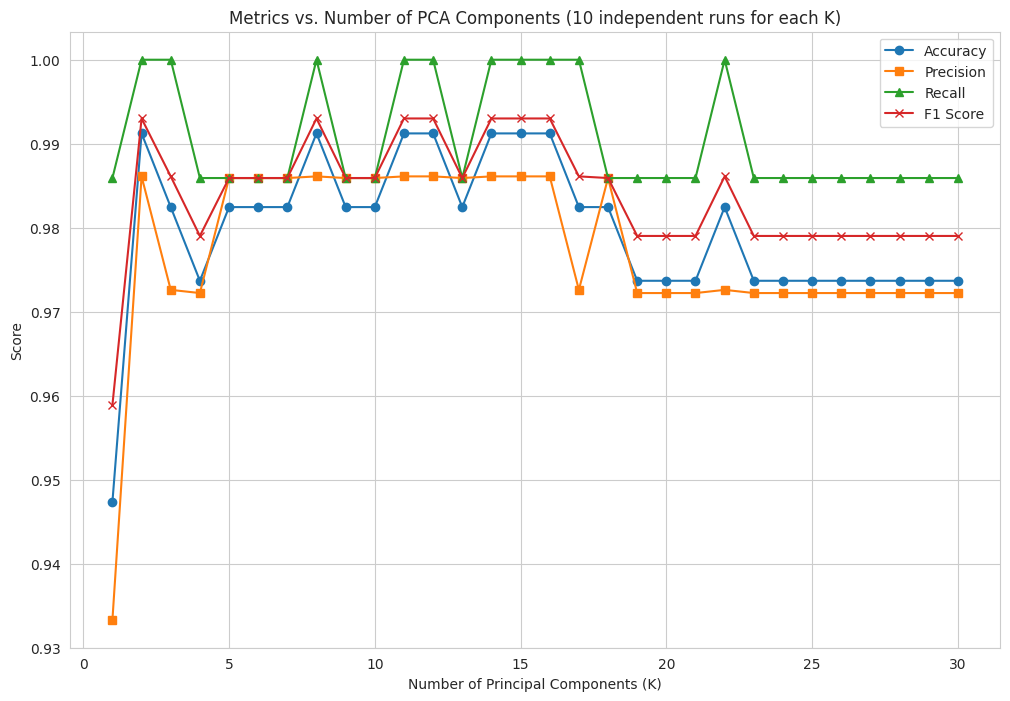

In [11]:
# Plot all metrics in one single plot
plt.figure(figsize=(12,8))
plt.plot(metrics_df['K'], metrics_df['Accuracy'], marker='o', label="Accuracy")
plt.plot(metrics_df['K'], metrics_df['Precision'], marker='s', label="Precision")
plt.plot(metrics_df['K'], metrics_df['Recall'], marker='^', label="Recall")
plt.plot(metrics_df['K'], metrics_df['F1 Score'], marker='x', label="F1 Score")
plt.xlabel("Number of Principal Components (K)")
plt.ylabel("Score")
plt.title("Metrics vs. Number of PCA Components ({} independent runs for each K)".format(n_runs))
plt.legend()
plt.grid(True)
plt.savefig("images/Combined_Metrics_vs_Number_of_PCA_Components.png")
plt.show()

Logistic Regression (PCA with Best K = 2) - Final Results:
Accuracy:  0.9912
Precision: 0.9861
Recall:    1.0000
F1 Score:  0.9930


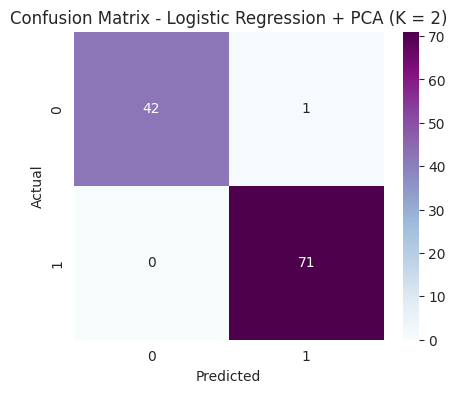

In [12]:
# Use the best K (with the highest average accuracy) to train a final Logistic Regression model
pca_best = PCA(n_components=best_k_acc)
X_train_pca_best = pca_best.fit_transform(X_train_scaled)
X_test_pca_best = pca_best.transform(X_test_scaled)

lr_pca_best = LogisticRegression(penalty='l2', C=1.0, max_iter=500)
lr_pca_best.fit(X_train_pca_best, y_train)
y_pred_best_pca = lr_pca_best.predict(X_test_pca_best)

# Evaluate final metrics using the best K
acc_best_pca = accuracy_score(y_test, y_pred_best_pca)
prec_best_pca = precision_score(y_test, y_pred_best_pca)
rec_best_pca = recall_score(y_test, y_pred_best_pca)
f1_best_pca = f1_score(y_test, y_pred_best_pca)

print("Logistic Regression (PCA with Best K = {}) - Final Results:".format(best_k_acc))
print("Accuracy:  {:.4f}".format(acc_best_pca))
print("Precision: {:.4f}".format(prec_best_pca))
print("Recall:    {:.4f}".format(rec_best_pca))
print("F1 Score:  {:.4f}".format(f1_best_pca))

# Plot confusion matrix for the final model using best K
cm_best_pca = confusion_matrix(y_test, y_pred_best_pca)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best_pca, annot=True, cmap='BuPu', fmt='g')
plt.title("Confusion Matrix - Logistic Regression + PCA (K = {})".format(best_k_acc))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/Confusion_Matrix-Logistic_Regression_PCA_BestK.png")
plt.show()

**Conclusion:**

PCA is applied to the standardized data, and the number of principal components (K) is varied from 1 to 30. For each K, 10 independent runs of logistic regression are performed, and the average performance metrics (accuracy, precision, recall, and F1 score) are computed. A table and combined plot are generated to visualize the metrics as functions of K.

**Results from the Analysis:**  
- The optimal number of principal components is determined to be K = 2.
- With K = 2, the final logistic regression model achieves the following metrics:  
  - **Accuracy:** 0.9912  
  - **Precision:** 0.9861  
  - **Recall:** 1.0000  
  - **F1 Score:** 0.9930  
- The combined metrics table and plot illustrate that performance peaks when using a low-dimensional representation, indicating that the majority of the discriminatory power is captured in just two components.
  
Dimensionality reduction via PCA notably simplifies the model without sacrificing performance. The finding that K = 2 is optimal suggests that nearly all essential information for classifying tumors is contained in two principal components. This reduction in dimensionality not only streamlines the model and reduces computational cost but also leads to an enhancement in performance metrics compared to using the full 30 features.

## Summary and Conclusions

The analysis of the Breast Cancer dataset confirms that the classification task is effectively supported by the available features. The following observations summarize the experimental findings:

- **Problem 1 (Logistic Regression):**  
  The baseline logistic regression model using all 30 features achieves very high accuracy, precision, recall, and F1 score. The introduction of a stronger weight penalty leads to improved recall (perfect detection of malignant cases) while marginally increasing overall performance. This confirms that proper scaling and regularization are critical in optimizing model performance.

- **Problem 2 (Naive Bayes Classifier):**  
  The Gaussian Naive Bayes classifier performs competitively, with high recall and decent accuracy. Although its performance is slightly lower than that of the logistic regression models, the simplicity and speed of Naive Bayes make it a viable alternative for rapid classification tasks.

- **Problem 3 (SVM Classifier):**  
  An SVM model with a linear kernel exhibits robust performance in the same high-performance range as the other classifiers. However, the marginally lower accuracy compared to logistic regression indicates that for this particular dataset, the simplicity of logistic regression proves more effective.

- **Problem 4 (Logistic Regression with PCA):**  
  The use of PCA for dimensionality reduction reveals that the critical discriminatory information can be captured in as few as two principal components. The final model with K = 2 not only achieves almost perfect classification performance but also significantly reduces model complexity. This suggests that the original 30 features contain a substantial degree of redundancy.

Overall, the results demonstrate that the Breast Cancer dataset is intrinsically separable, allowing various classifiers to achieve very high diagnostic accuracy. The integration of regularization and dimensionality reduction techniques further enhances performance and reduces complexity, confirming the efficacy of these methods in designing robust diagnostic models.